In [2]:
!pip install pandas

  Using cached tzdata-2025.3-py2.py3-none-any.whl.metadata (1.4 kB)
   ---------------------------------------- 0.0/11.4 MB ? eta -:--:--
   ---------- ----------------------------- 2.9/11.4 MB 21.0 MB/s eta 0:00:01
   ---------------------- ----------------- 6.3/11.4 MB 18.4 MB/s eta 0:00:01
   ---------------------------- ----------- 8.1/11.4 MB 14.4 MB/s eta 0:00:01
   ---------------------------------- ----- 9.7/11.4 MB 12.6 MB/s eta 0:00:01
   -------------------------------------- - 11.0/11.4 MB 11.5 MB/s eta 0:00:01
   ---------------------------------------- 11.4/11.4 MB 10.9 MB/s  0:00:01
Using cached tzdata-2025.3-py2.py3-none-any.whl (348 kB)

   ---------------------------------------- 0/3 [pytz]
   ------------- -------------------------- 1/3 [tzdata]
   ------------- -------------------------- 1/3 [tzdata]
   ------------- -------------------------- 1/3 [tzdata]
   -------------------------- ------------- 2/3 [pandas]
   -------------------------- ------------- 2/3 [panda

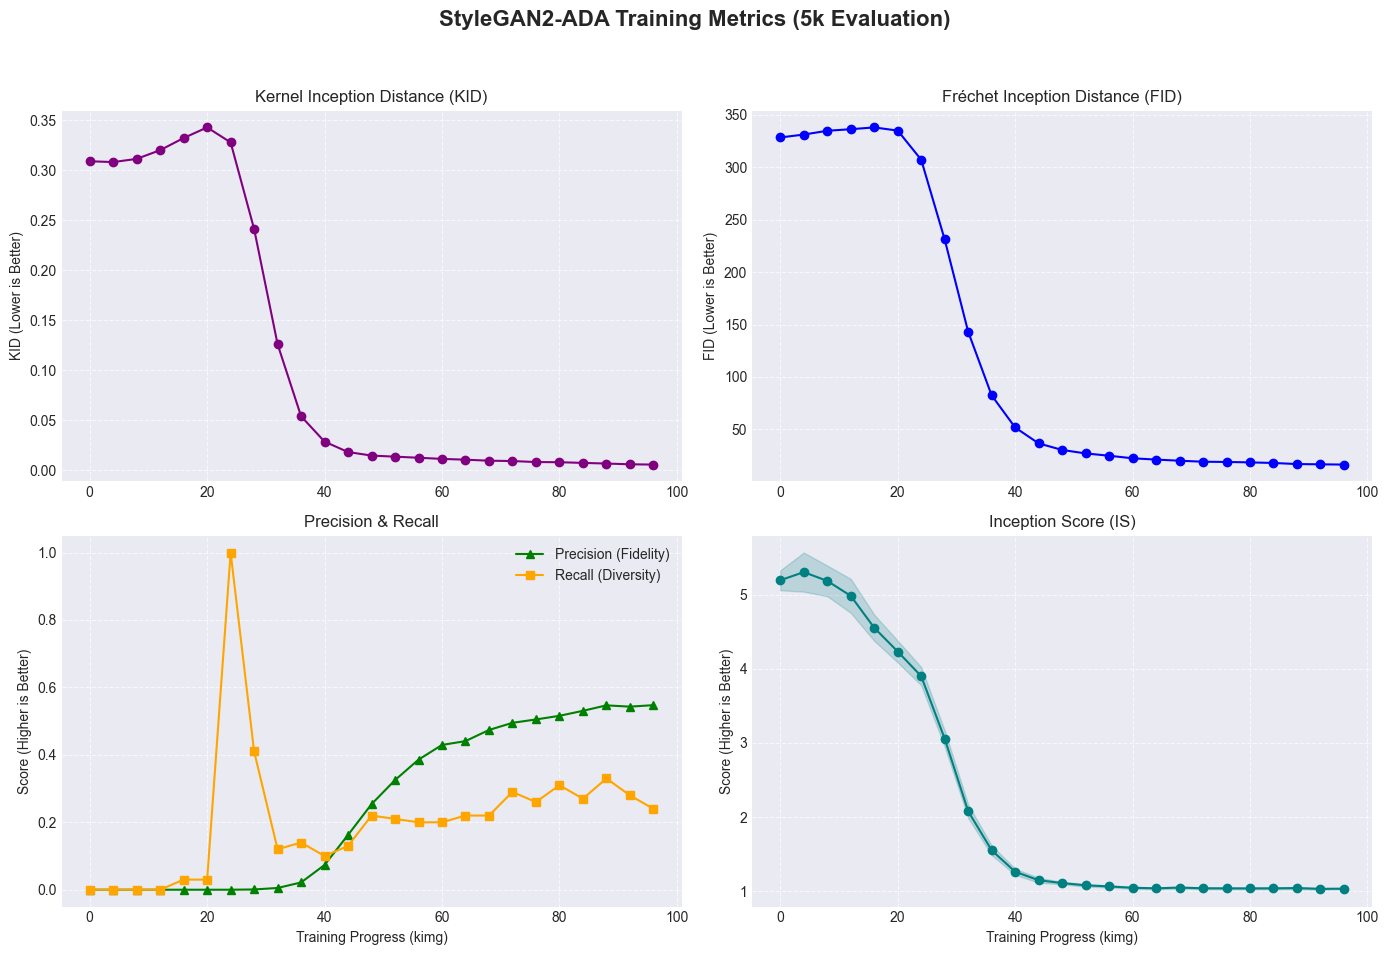

In [4]:
import os
import json
import matplotlib.pyplot as plt

import sys
BASE_DIR = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))


# --- CONFIGURATION ---
RUN_DIR = os.path.join(BASE_DIR, "src", "stylegan2-ADA-pytorch", "training-runs", "00012-panda-mirror-paper256-kimg200-resumecustom")

def load_metric(metric_name, key_names):
    """Reads a JSONL file and returns a dictionary of {kimg: {key: value}}."""
    file_path = os.path.join(RUN_DIR, f"metric-{metric_name}.jsonl")
    data = {}
    
    if not os.path.exists(file_path):
        print(f"Warning: Could not find {file_path}")
        return data

    with open(file_path, 'rt') as f:
        for line in f:
            entry = json.loads(line)
            # Extract the kimg number from the filename (e.g., "network-snapshot-000004.pkl" -> 4)
            pkl_name = entry['snapshot_pkl']
            kimg = int(pkl_name.split('-')[-1].split('.')[0])
            
            # Store the requested keys
            data[kimg] = {k: entry['results'][k] for k in key_names}
            
    return data

# --- 1. LOAD ALL DATA ---
kid_data = load_metric('kid5k_full', ['kid5k_full'])
fid_data = load_metric('fid5k_full', ['fid5k_full'])
pr_data  = load_metric('pr5k3_full', ['pr5k3_full_precision', 'pr5k3_full_recall'])
is_data  = load_metric('is5k',       ['is5k_mean', 'is5k_std'])

# Sort by kimg (X-axis)
kimgs = sorted(list(kid_data.keys()))

# --- 2. EXTRACT ARRAYS FOR PLOTTING ---
x_kid = sorted(kid_data.keys())
y_kid = [kid_data[k]['kid5k_full'] for k in x_kid]

x_fid = sorted(fid_data.keys())
y_fid = [fid_data[k]['fid5k_full'] for k in x_fid]

x_pr = sorted(pr_data.keys())
y_precision = [pr_data[k]['pr5k3_full_precision'] for k in x_pr]
y_recall    = [pr_data[k]['pr5k3_full_recall'] for k in x_pr]

x_is = sorted(is_data.keys())
y_is_mean = [is_data[k]['is5k_mean'] for k in x_is]
y_is_std  = [is_data[k]['is5k_std'] for k in x_is]

# --- 3. CREATE THE DASHBOARD ---
fig, axs = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('StyleGAN2-ADA Training Metrics (5k Evaluation)', fontsize=16, fontweight='bold')

# Plot 1: KID (Lower is better)
axs[0, 0].plot(x_kid, y_kid, marker='o', color='purple')
axs[0, 0].set_title('Kernel Inception Distance (KID)')
axs[0, 0].set_ylabel('KID (Lower is Better)')
axs[0, 0].grid(True, linestyle='--', alpha=0.7)

# Plot 2: FID (Lower is better)
axs[0, 1].plot(x_fid, y_fid, marker='o', color='blue')
axs[0, 1].set_title('Fréchet Inception Distance (FID)')
axs[0, 1].set_ylabel('FID (Lower is Better)')
axs[0, 1].grid(True, linestyle='--', alpha=0.7)

# Plot 3: Precision & Recall (Higher is better)
axs[1, 0].plot(x_pr, y_precision, marker='^', color='green', label='Precision (Fidelity)')
axs[1, 0].plot(x_pr, y_recall, marker='s', color='orange', label='Recall (Diversity)')
axs[1, 0].set_title('Precision & Recall')
axs[1, 0].set_ylabel('Score (Higher is Better)')
axs[1, 0].set_xlabel('Training Progress (kimg)')
axs[1, 0].legend()
axs[1, 0].grid(True, linestyle='--', alpha=0.7)

# Plot 4: Inception Score (Higher is better)
axs[1, 1].plot(x_is, y_is_mean, marker='o', color='teal')
axs[1, 1].fill_between(x_is, 
                       [m - s for m, s in zip(y_is_mean, y_is_std)], 
                       [m + s for m, s in zip(y_is_mean, y_is_std)], 
                       color='teal', alpha=0.2)
axs[1, 1].set_title('Inception Score (IS)')
axs[1, 1].set_ylabel('Score (Higher is Better)')
axs[1, 1].set_xlabel('Training Progress (kimg)')
axs[1, 1].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout so title fits
plt.show()